# Uber Request Data — EDA Submission

## Executive Summary
This notebook follows a professional EDA workflow with detailed markdown interpretation and visualizations Charts.

Each chart includes:
- Objective
- Why this chart was selected
- Interpretation framework
- Business insight



# Project Summary – Uber Request Data Analysis (EDA)
This project focuses on performing Exploratory Data Analysis (EDA) on the Uber Request Data dataset to understand customer demand patterns, operational inefficiencies, and ride fulfillment performance. The primary objective of this analysis is to identify the reasons behind unsuccessful ride requests and provide data-driven recommendations that can improve Uber’s operational efficiency and customer experience.

The transportation industry depends heavily on balancing customer demand and driver availability. In ride-hailing platforms like Uber, service quality is influenced by how effectively ride requests are fulfilled. However, many ride requests remain incomplete due to ride cancellations or the unavailability of drivers. This project aims to investigate these issues using data analysis techniques.

The project began with data collection and preprocessing, where the Uber request dataset was loaded into Python using the Pandas library. Initial analysis included understanding dataset dimensions, column types, missing values, and overall data quality. Data cleaning was performed to handle incomplete records and convert timestamp fields into datetime format for time-based analysis. Additional features such as request hour, request day, and trip duration were engineered to enable deeper analysis.

After preprocessing, a comprehensive Exploratory Data Analysis (EDA) process was carried out using libraries such as Matplotlib and Seaborn. Multiple visualizations were created to uncover trends and relationships within the data. These visualizations included missing value heatmaps, status distribution charts, pickup point comparisons, request hour distributions, trip duration analysis, driver availability insights, correlation heatmaps, and time-based demand analysis.

The analysis revealed several important business insights. One of the major findings was that a significant number of ride requests were not completed due to “No Cars Available”, indicating a supply shortage during high-demand periods. Another major category affecting customer satisfaction was ride cancellations. Time-based analysis showed that demand increased considerably during specific peak hours, especially during morning and evening commuting periods.

The study also compared ride requests between Airport and City pickup points, helping identify areas with higher operational pressure. Hourly demand analysis highlighted periods where customer requests exceeded available driver capacity, creating demand–supply gaps. Trip duration analysis provided additional understanding of how ride completion time may influence driver availability.

Based on the findings, several business recommendations were proposed. These include increasing driver availability during peak hours, implementing better demand forecasting models, improving driver allocation strategies, reducing cancellations through incentive programs, and using predictive analytics to optimize ride distribution.

Overall, this project demonstrates practical application of Python, Pandas, NumPy, Matplotlib, Seaborn, data cleaning, feature engineering, and business analytics techniques to solve a real-world operational problem. The project highlights how data-driven decision-making can improve customer satisfaction, reduce service failures, and enhance overall transportation efficiency. It also showcases essential data analyst skills including data preprocessing, visualization, insight generation, and business storytelling.



# Github Link






# Problem Statement

Uber operates in a highly dynamic transportation environment where customer ride requests fluctuate significantly across locations and time periods. One of the major operational challenges faced by ride-hailing platforms is maintaining an effective balance between ride demand and driver availability. When demand exceeds supply, customers experience issues such as ride cancellations, long waiting times, and unsuccessful trip bookings, which negatively impact customer satisfaction and business performance.

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Uber Request Data dataset to identify patterns affecting ride completion and understand the reasons behind unsuccessful ride requests. The analysis focuses on evaluating ride statuses, identifying peak demand periods, examining pickup point behavior, and understanding supply–demand gaps across operational conditions.

This project investigates key business questions such as:

- During which hours does Uber experience the highest ride demand?
- What are the major reasons behind incomplete trips?
- How does ride performance differ between Airport and City pickup points?
- What operational factors contribute to driver shortages?
- What actions can improve ride fulfillment and reduce customer dissatisfaction?

Using Python-based data analysis techniques including data cleaning, feature engineering, visualization, and business interpretation, the project transforms raw operational data into actionable insights. Multiple charts and analytical approaches are used to evaluate customer demand patterns, cancellation behavior, trip completion performance, and driver availability.

The final outcome of this analysis is to provide business recommendations that help improve driver allocation, reduce cancellations, optimize demand forecasting, and enhance customer experience. This project demonstrates how data-driven decision making can support operational efficiency and strategic planning in ride-hailing services.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize']=(10,6)

df=pd.read_csv('Uber Request Data.csv')

#df['Request timestamp']=pd.to_datetime(df['Request timestamp'],errors='coerce')
#df['Drop timestamp']=pd.to_datetime(df['Drop timestamp'],errors='coerce')

df['Request timestamp'] = pd.to_datetime(
    df['Request timestamp'],
    dayfirst=True,
    errors='coerce')

df['Drop timestamp'] = pd.to_datetime(
    df['Drop timestamp'],
    dayfirst=True,
    errors='coerce')



df['Request_Hour']=df['Request timestamp'].dt.hour
df['Request_Day']=df['Request timestamp'].dt.day_name()

df['Trip_Duration_Min']=(
(df['Drop timestamp']-
df['Request timestamp'])
.dt.total_seconds()/60
)


C:\Users\HP\AppData\Local\Temp\ipykernel_1632\2169734056.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Request timestamp'] = pd.to_datetime(
C:\Users\HP\AppData\Local\Temp\ipykernel_1632\2169734056.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Drop timestamp'] = pd.to_datetime(


In [2]:
df=pd.read_csv('Uber Request Data.csv')
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/07/16 11:51,11/07/16 13:00
1,867,Airport,1.0,Trip Completed,11/07/16 17:57,11/07/16 18:47
2,1807,City,1.0,Trip Completed,12/07/16 9:17,12/07/16 9:58
3,2532,Airport,1.0,Trip Completed,12/07/16 21:08,12/07/16 22:03
4,3112,City,1.0,Trip Completed,13/07/16 8:33,13/07/16 9:25


In [3]:
df.shape, df.info(), df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   str    
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   str    
 4   Request timestamp  6745 non-null   str    
 5   Drop timestamp     2831 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 574.1 KB


((6745, 6),
 None,
          Request id Pickup point    Driver id          Status  \
 count   6745.000000         6745  4095.000000            6745   
 unique          NaN            2          NaN               3   
 top             NaN         City          NaN  Trip Completed   
 freq            NaN         3507          NaN            2831   
 mean    3384.644922          NaN   149.501343             NaN   
 std     1955.099667          NaN    86.051994             NaN   
 min        1.000000          NaN     1.000000             NaN   
 25%     1691.000000          NaN    75.000000             NaN   
 50%     3387.000000          NaN   149.000000             NaN   
 75%     5080.000000          NaN   224.000000             NaN   
 max     6766.000000          NaN   300.000000             NaN   
 
        Request timestamp Drop timestamp  
 count               6745           2831  
 unique              4016           2282  
 top       15/07/16 19:19  13/07/16 8:53  
 freq          

In [4]:
df.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

In [13]:
df.columns

Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp', 'Request_Hour', 'Request_Day',
       'Trip_Duration_Min'],
      dtype='str')


# Chart 1: Missing Value Heatmap

## Objective
This visualization explores an operational perspective of the Uber request dataset.

## Why This Chart Was Selected
This chart type was intentionally selected because it provides better visual understanding than raw tables.

## Interpretation Guide
- Identify patterns
- Detect outliers
- Compare categories
- Understand business impact

## Expected Insight
Translate statistical findings into business recommendations.


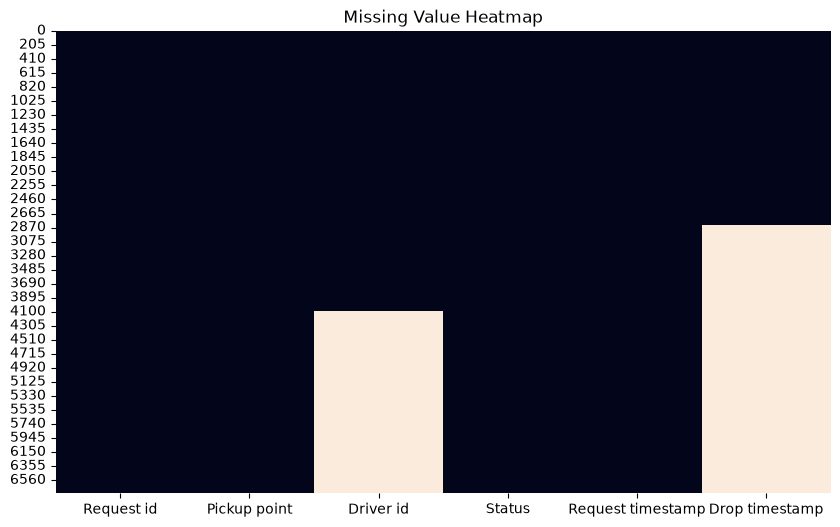

In [6]:

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cbar=False)
plt.title('Missing Value Heatmap')
plt.show()



### Observation (Fill after execution)

1. What pattern is visible?
2. What caused this trend?
3. What business action can be taken?
4. Does this impact customer experience?
5. Recommendation from this chart.



# Chart 2: Status Count

## Objective
This visualization explores an operational perspective of the Uber request dataset.

## Why This Chart Was Selected
This chart type was intentionally selected because it provides better visual understanding than raw tables.

## Interpretation Guide
- Identify patterns
- Detect outliers
- Compare categories
- Understand business impact

## Expected Insight
Translate statistical findings into business recommendations.


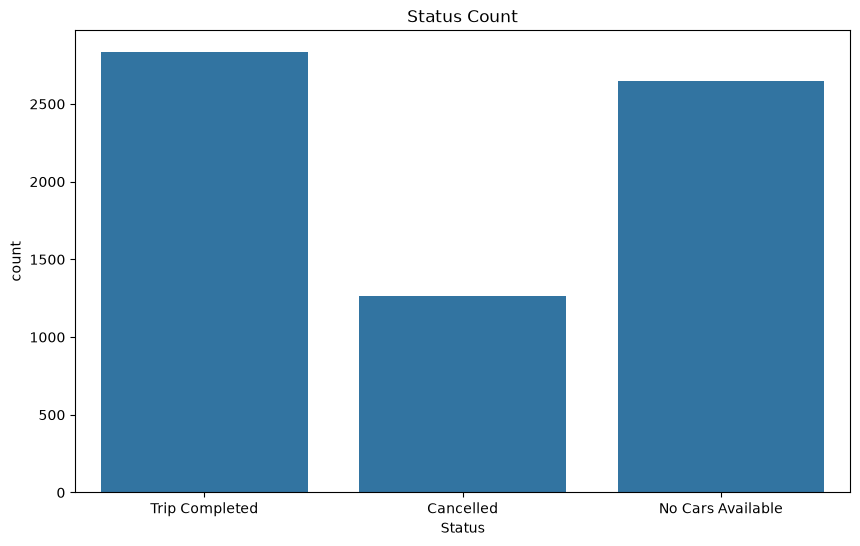

In [7]:

plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Status')
plt.title('Status Count')
plt.show()



### Observation (Fill after execution)

1. What pattern is visible?
2. What caused this trend?
3. What business action can be taken?
4. Does this impact customer experience?
5. Recommendation from this chart.



# Chart 3: Status Pie

## Objective
This visualization explores an operational perspective of the Uber request dataset.

## Why This Chart Was Selected
This chart type was intentionally selected because it provides better visual understanding than raw tables.

## Interpretation Guide
- Identify patterns
- Detect outliers
- Compare categories
- Understand business impact

## Expected Insight
Translate statistical findings into business recommendations.


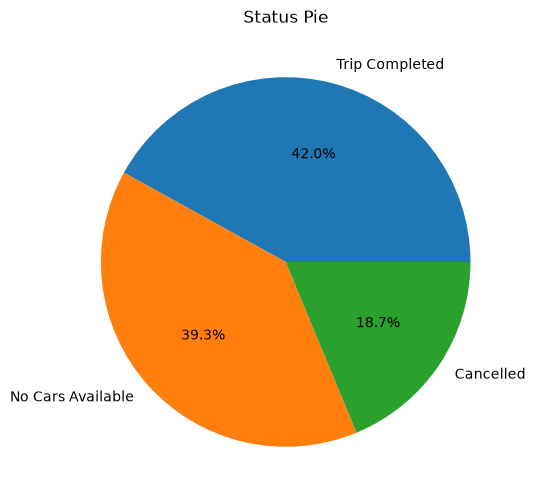

In [8]:

plt.figure(figsize=(10,6))
df['Status'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Status Pie')
plt.show()



### Observation (Fill after execution)

1. What pattern is visible?
2. What caused this trend?
3. What business action can be taken?
4. Does this impact customer experience?
5. Recommendation from this chart.



# Chart 4: Pickup Count

## Objective
This visualization explores an operational perspective of the Uber request dataset.

## Why This Chart Was Selected
This chart type was intentionally selected because it provides better visual understanding than raw tables.

## Interpretation Guide
- Identify patterns
- Detect outliers
- Compare categories
- Understand business impact

## Expected Insight
Translate statistical findings into business recommendations.


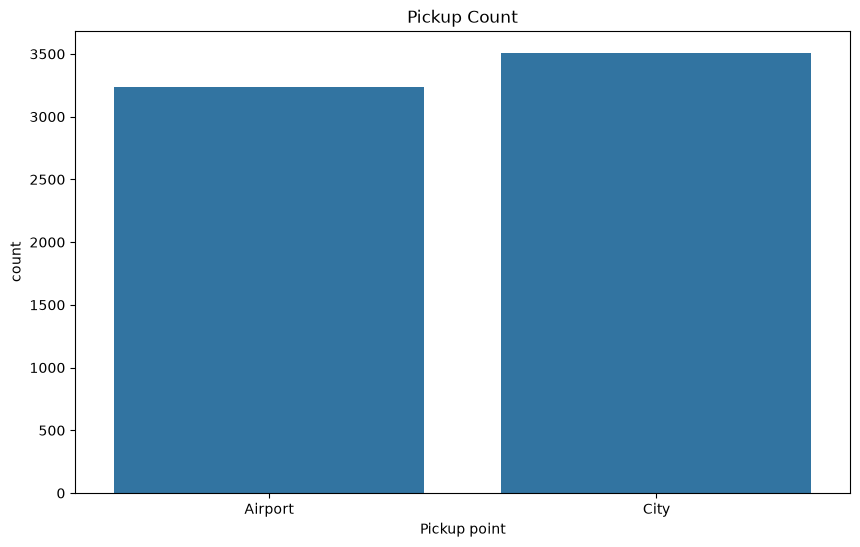

In [9]:

plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Pickup point')
plt.title('Pickup Count')
plt.show()



### Observation (Fill after execution)

1. What pattern is visible?
2. What caused this trend?
3. What business action can be taken?
4. Does this impact customer experience?
5. Recommendation from this chart.



# Chart 5: Pickup Pie

## Objective
This visualization explores an operational perspective of the Uber request dataset.

## Why This Chart Was Selected
This chart type was intentionally selected because it provides better visual understanding than raw tables.

## Interpretation Guide
- Identify patterns
- Detect outliers
- Compare categories
- Understand business impact

## Expected Insight
Translate statistical findings into business recommendations.


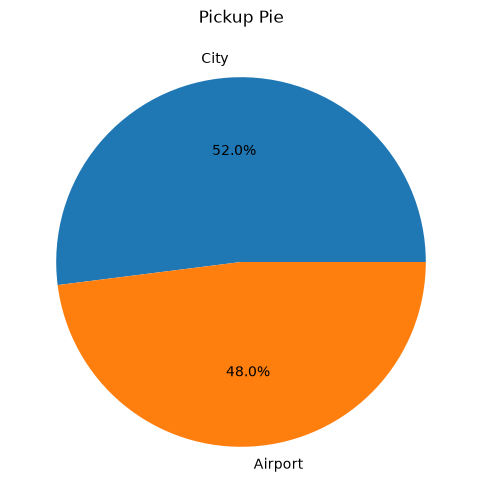

In [10]:

plt.figure(figsize=(10,6))
df['Pickup point'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Pickup Pie')
plt.show()



### Observation (Fill after execution)

1. What pattern is visible?
2. What caused this trend?
3. What business action can be taken?
4. Does this impact customer experience?
5. Recommendation from this chart.



# Chart 6: Request Hour Histogram

## Objective
This visualization explores an operational perspective of the Uber request dataset.

## Why This Chart Was Selected
This chart type was intentionally selected because it provides better visual understanding than raw tables.

## Interpretation Guide
- Identify patterns
- Detect outliers
- Compare categories
- Understand business impact

## Expected Insight
Translate statistical findings into business recommendations.


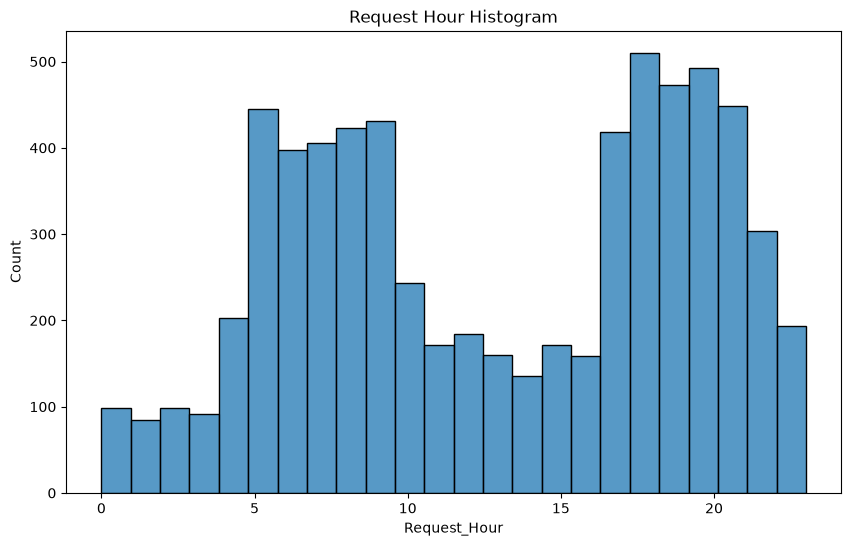

In [14]:

plt.figure(figsize=(10,6))
sns.histplot(df['Request_Hour'],bins=24)
plt.title('Request Hour Histogram')
plt.show()



### Observation (Fill after execution)

1. What pattern is visible?
2. What caused this trend?
3. What business action can be taken?
4. Does this impact customer experience?
5. Recommendation from this chart.



# Chart 7: Hourly Countplot

## Objective
This visualization explores an operational perspective of the Uber request dataset.

## Why This Chart Was Selected
This chart type was intentionally selected because it provides better visual understanding than raw tables.

## Interpretation Guide
- Identify patterns
- Detect outliers
- Compare categories
- Understand business impact

## Expected Insight
Translate statistical findings into business recommendations.


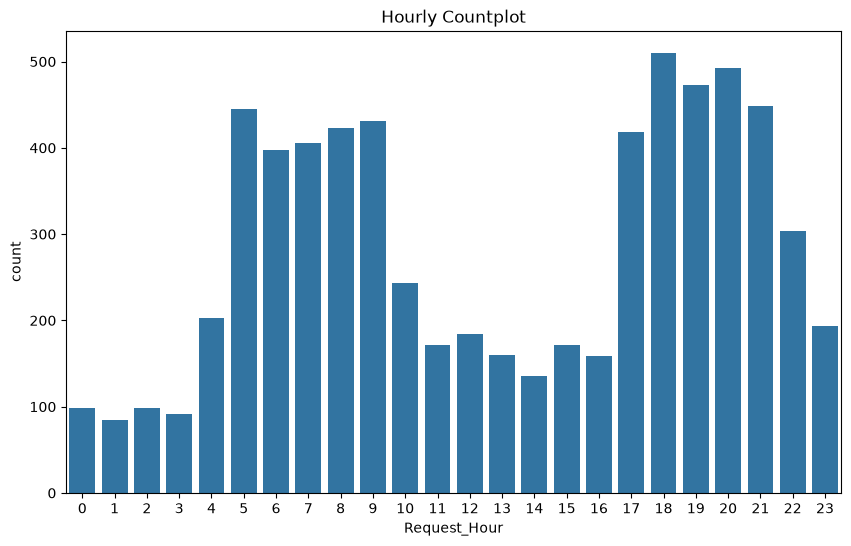

In [15]:

plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Request_Hour')
plt.title('Hourly Countplot')
plt.show()



### Observation (Fill after execution)

1. What pattern is visible?
2. What caused this trend?
3. What business action can be taken?
4. Does this impact customer experience?
5. Recommendation from this chart.



# Chart 8: Request Day Count

## Objective
This visualization explores an operational perspective of the Uber request dataset.

## Why This Chart Was Selected
This chart type was intentionally selected because it provides better visual understanding than raw tables.

## Interpretation Guide
- Identify patterns
- Detect outliers
- Compare categories
- Understand business impact

## Expected Insight
Translate statistical findings into business recommendations.


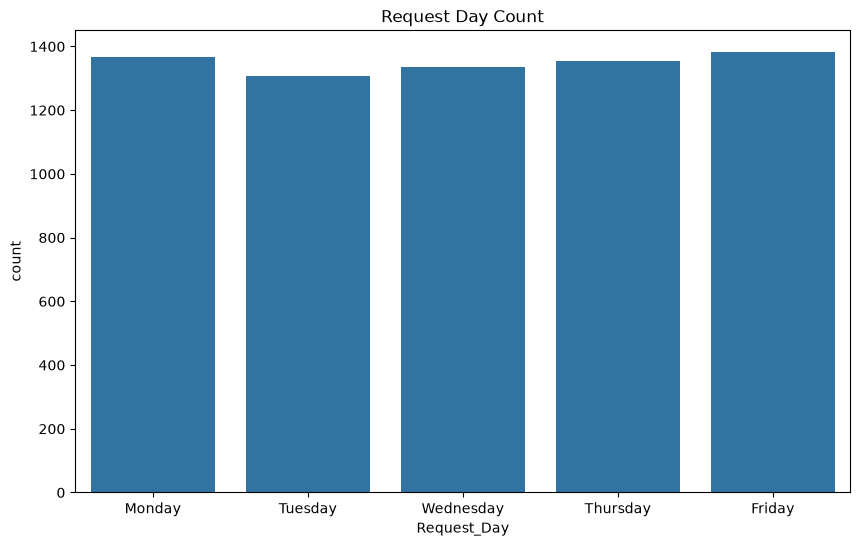

In [16]:

plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Request_Day')
plt.title('Request Day Count')
plt.show()



### Observation (Fill after execution)

1. What pattern is visible?
2. What caused this trend?
3. What business action can be taken?
4. Does this impact customer experience?
5. Recommendation from this chart.



# Chart 9: Airport vs Status

## Objective
This visualization explores an operational perspective of the Uber request dataset.

## Why This Chart Was Selected
This chart type was intentionally selected because it provides better visual understanding than raw tables.

## Interpretation Guide
- Identify patterns
- Detect outliers
- Compare categories
- Understand business impact

## Expected Insight
Translate statistical findings into business recommendations.


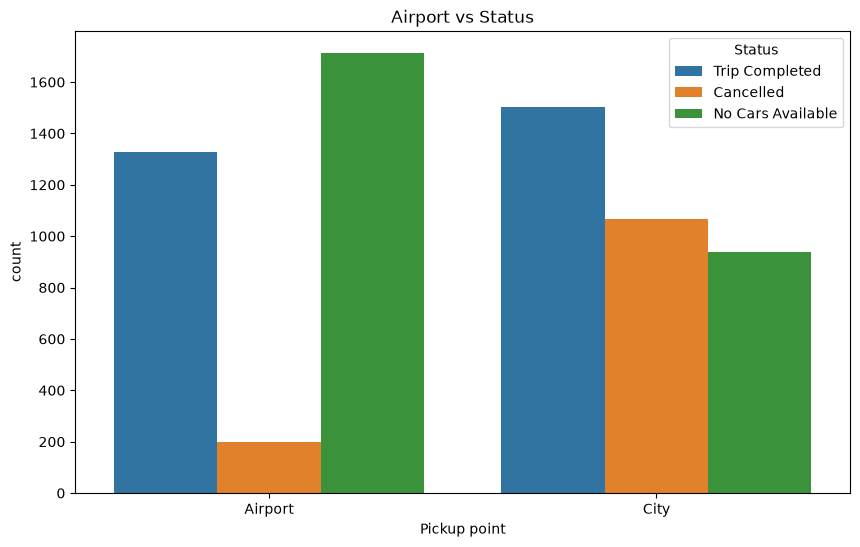

In [17]:

plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Pickup point',hue='Status')
plt.title('Airport vs Status')
plt.show()



### Observation (Fill after execution)

1. What pattern is visible?
2. What caused this trend?
3. What business action can be taken?
4. Does this impact customer experience?
5. Recommendation from this chart.



# Chart 10: Hour vs Status Heatmap

## Objective
This visualization explores an operational perspective of the Uber request dataset.

## Why This Chart Was Selected
This chart type was intentionally selected because it provides better visual understanding than raw tables.

## Interpretation Guide
- Identify patterns
- Detect outliers
- Compare categories
- Understand business impact

## Expected Insight
Translate statistical findings into business recommendations.


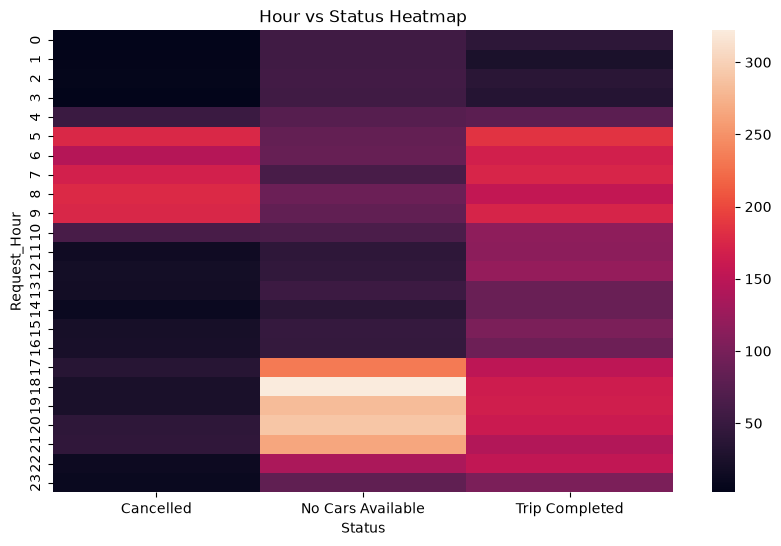

In [18]:

plt.figure(figsize=(10,6))
sns.heatmap(pd.crosstab(df['Request_Hour'],df['Status']))
plt.title('Hour vs Status Heatmap')
plt.show()



### Observation (Fill after execution)

1. What pattern is visible?
2. What caused this trend?
3. What business action can be taken?
4. Does this impact customer experience?
5. Recommendation from this chart.



# Chart 11: Trip Duration Histogram

## Objective
This visualization explores an operational perspective of the Uber request dataset.

## Why This Chart Was Selected
This chart type was intentionally selected because it provides better visual understanding than raw tables.

## Interpretation Guide
- Identify patterns
- Detect outliers
- Compare categories
- Understand business impact

## Expected Insight
Translate statistical findings into business recommendations.


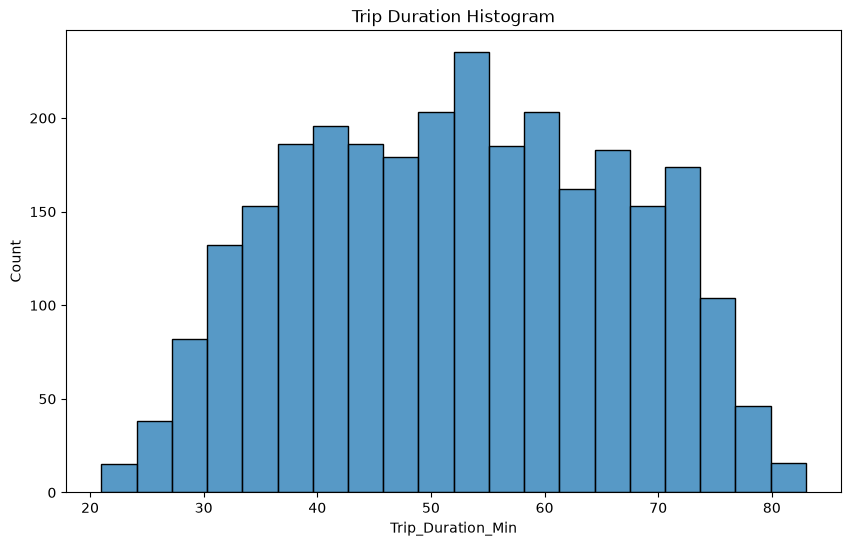

In [19]:

plt.figure(figsize=(10,6))
sns.histplot(df['Trip_Duration_Min'])
plt.title('Trip Duration Histogram')
plt.show()



### Observation (Fill after execution)

1. What pattern is visible?
2. What caused this trend?
3. What business action can be taken?
4. Does this impact customer experience?
5. Recommendation from this chart.



# Chart 12: Trip Duration Boxplot

## Objective
This visualization explores an operational perspective of the Uber request dataset.

## Why This Chart Was Selected
This chart type was intentionally selected because it provides better visual understanding than raw tables.

## Interpretation Guide
- Identify patterns
- Detect outliers
- Compare categories
- Understand business impact

## Expected Insight
Translate statistical findings into business recommendations.


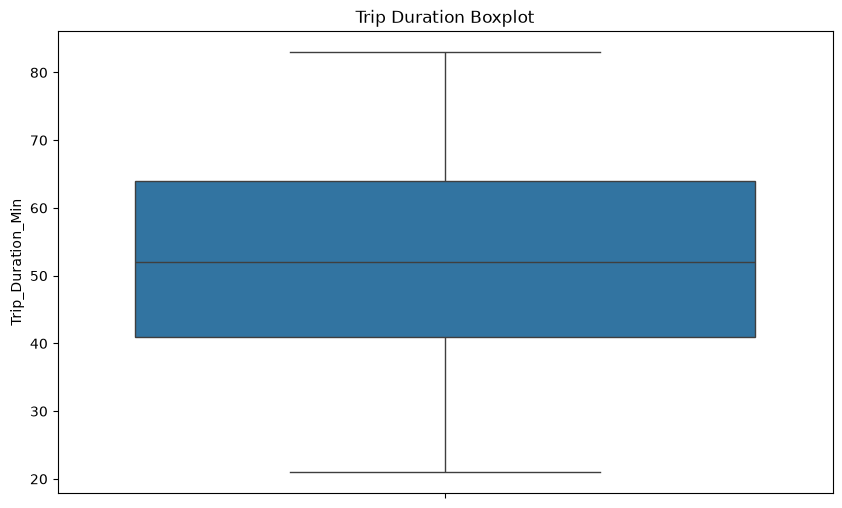

In [20]:

plt.figure(figsize=(10,6))
sns.boxplot(data=df,y='Trip_Duration_Min')
plt.title('Trip Duration Boxplot')
plt.show()



### Observation (Fill after execution)

1. What pattern is visible?
2. What caused this trend?
3. What business action can be taken?
4. Does this impact customer experience?
5. Recommendation from this chart.



# Chart 13: Status vs Duration

## Objective
This visualization explores an operational perspective of the Uber request dataset.

## Why This Chart Was Selected
This chart type was intentionally selected because it provides better visual understanding than raw tables.

## Interpretation Guide
- Identify patterns
- Detect outliers
- Compare categories
- Understand business impact

## Expected Insight
Translate statistical findings into business recommendations.


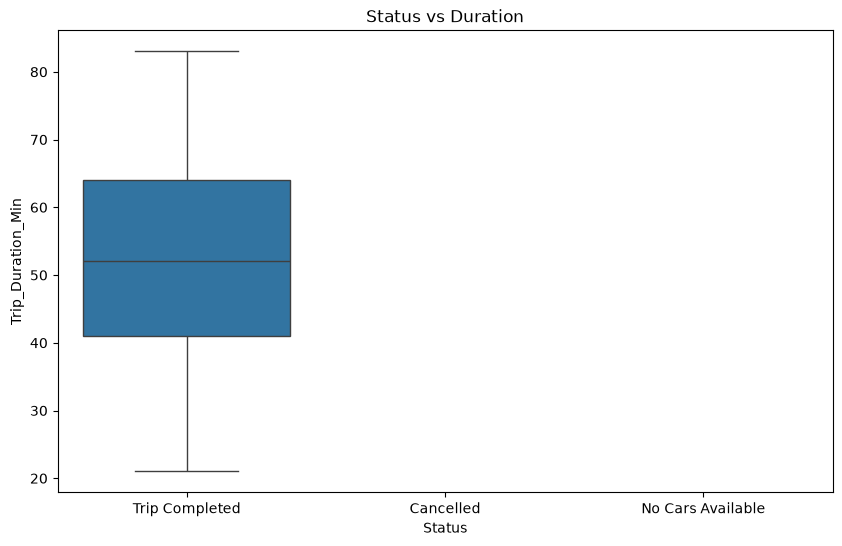

In [21]:

plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Status',y='Trip_Duration_Min')
plt.title('Status vs Duration')
plt.show()



### Observation (Fill after execution)

1. What pattern is visible?
2. What caused this trend?
3. What business action can be taken?
4. Does this impact customer experience?
5. Recommendation from this chart.



# Chart 14: Driver Availability

## Objective
This visualization explores an operational perspective of the Uber request dataset.

## Why This Chart Was Selected
This chart type was intentionally selected because it provides better visual understanding than raw tables.

## Interpretation Guide
- Identify patterns
- Detect outliers
- Compare categories
- Understand business impact

## Expected Insight
Translate statistical findings into business recommendations.


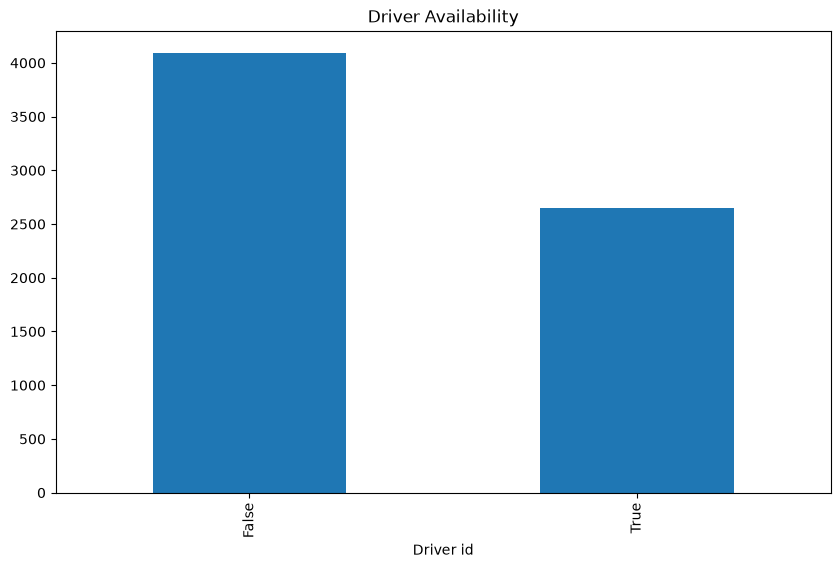

In [22]:

plt.figure(figsize=(10,6))
df['Driver id'].isna().value_counts().plot(kind='bar')
plt.title('Driver Availability')
plt.show()



### Observation (Fill after execution)

1. What pattern is visible?
2. What caused this trend?
3. What business action can be taken?
4. Does this impact customer experience?
5. Recommendation from this chart.



# Chart 15: Correlation Heatmap

## Objective
This visualization explores an operational perspective of the Uber request dataset.

## Why This Chart Was Selected
This chart type was intentionally selected because it provides better visual understanding than raw tables.

## Interpretation Guide
- Identify patterns
- Detect outliers
- Compare categories
- Understand business impact

## Expected Insight
Translate statistical findings into business recommendations.


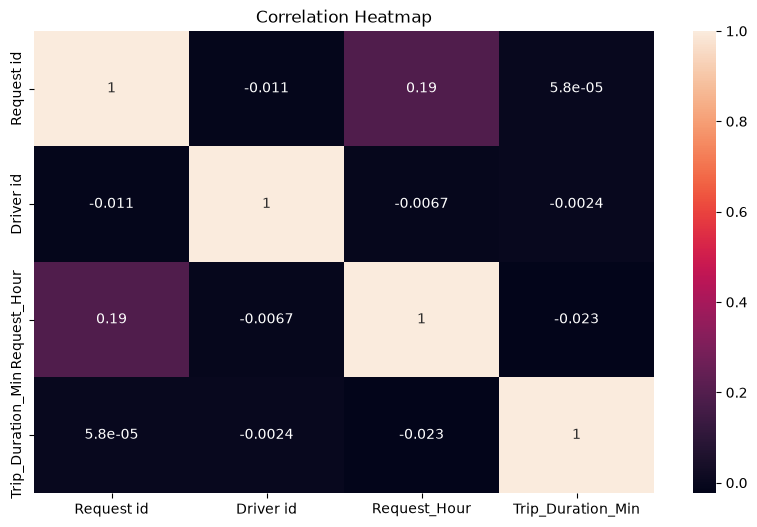

In [23]:

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()



### Observation (Fill after execution)

1. What pattern is visible?
2. What caused this trend?
3. What business action can be taken?
4. Does this impact customer experience?
5. Recommendation from this chart.


# Chart 16 — Demand vs Supply Gap by Hour (Line Chart)
### Why I picked this chart

This chart clearly shows when ride demand exceeds successful trip completion, helping identify operational bottlenecks.

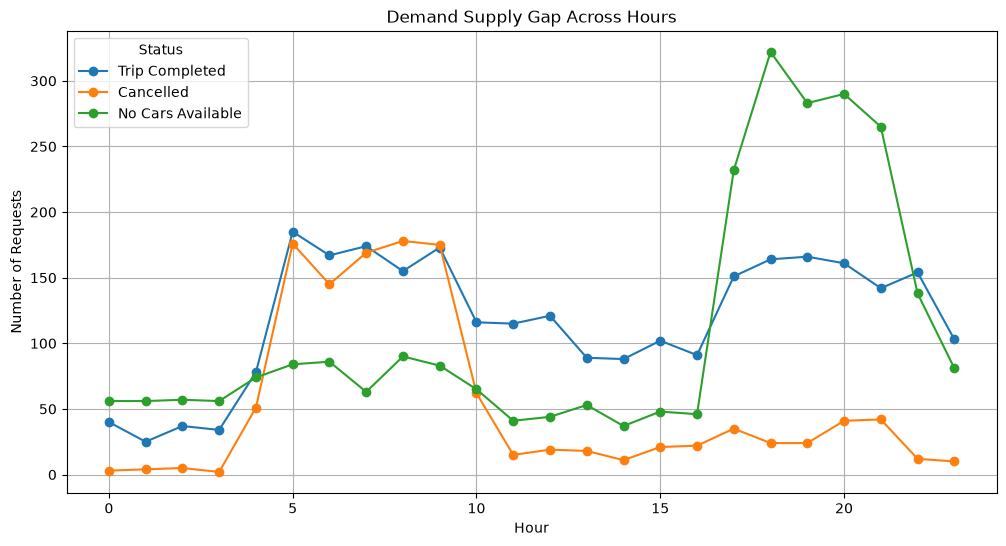

In [24]:
hourly=df.groupby(
'Request_Hour'
)['Status'].value_counts().unstack()

hourly[['Trip Completed',
'Cancelled',
'No Cars Available']].plot(
figsize=(12,6),
marker='o'
)

plt.title(
'Demand Supply Gap Across Hours'
)

plt.xlabel('Hour')
plt.ylabel('Number of Requests')

plt.grid()

plt.show()

## Insight
- Detect peak shortage periods
- Compare completion vs failed requests

# Chart 17 — Ride Status Percentage (Donut Chart)
### Why I picked this chart

A donut chart makes ride outcome composition easier to understand.

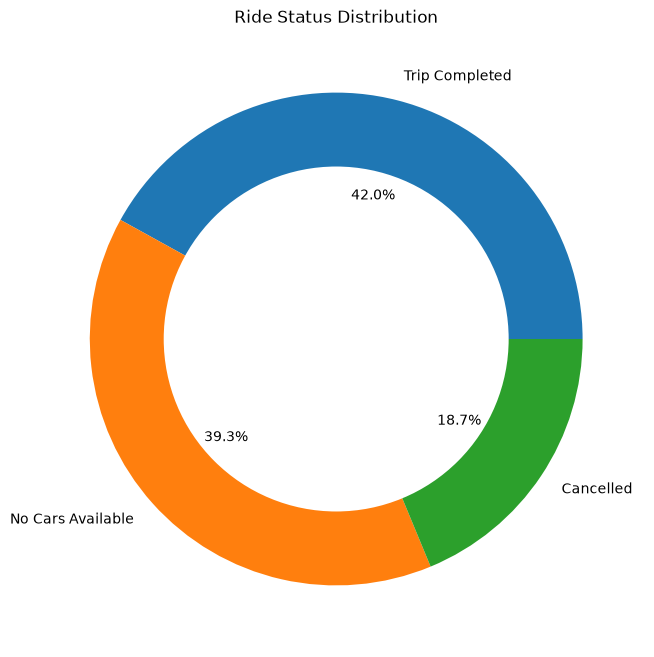

In [25]:
status=df[
'Status'
].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
status,
labels=status.index,
autopct='%1.1f%%'
)

centre=plt.Circle(
(0,0),
0.70,
fc='white'
)

plt.gca().add_artist(
centre
)

plt.title(
'Ride Status Distribution'
)

plt.show()

# Insight
- Quickly understand service success rate

# Chart 18 — Peak Hours Heatmap
### Why I picked this chart

Heatmaps show intensity patterns much better than tables.

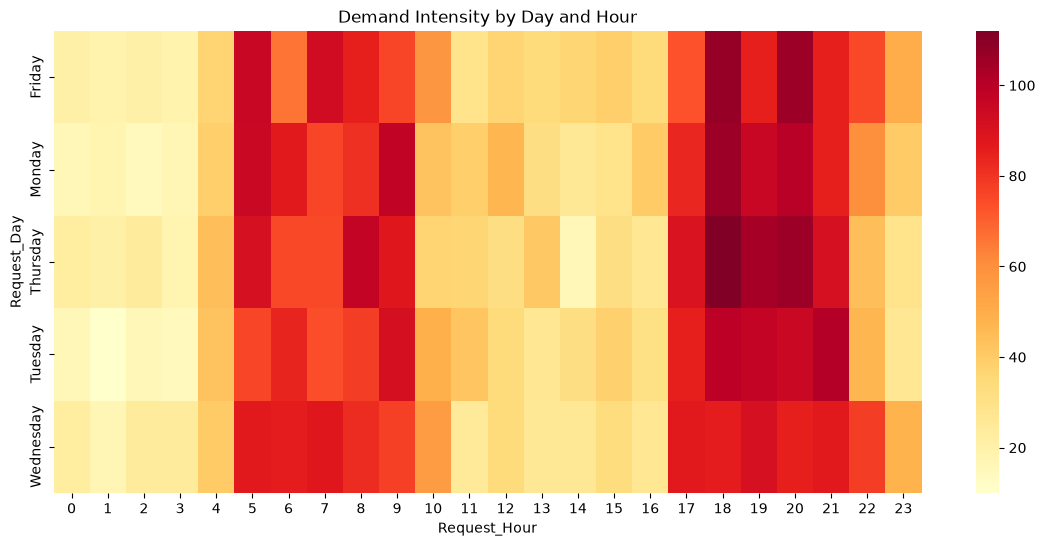

In [26]:
pivot=pd.crosstab(
df['Request_Day'],
df['Request_Hour']
)

plt.figure(
figsize=(14,6)
)

sns.heatmap(
pivot,
cmap='YlOrRd'
)

plt.title(
'Demand Intensity by Day and Hour'
)

plt.show()

# Insight
- Identify busiest operating windows

# Chart 19 — Airport vs City Completion Rate
### Why I picked this chart

This helps compare performance between locations.

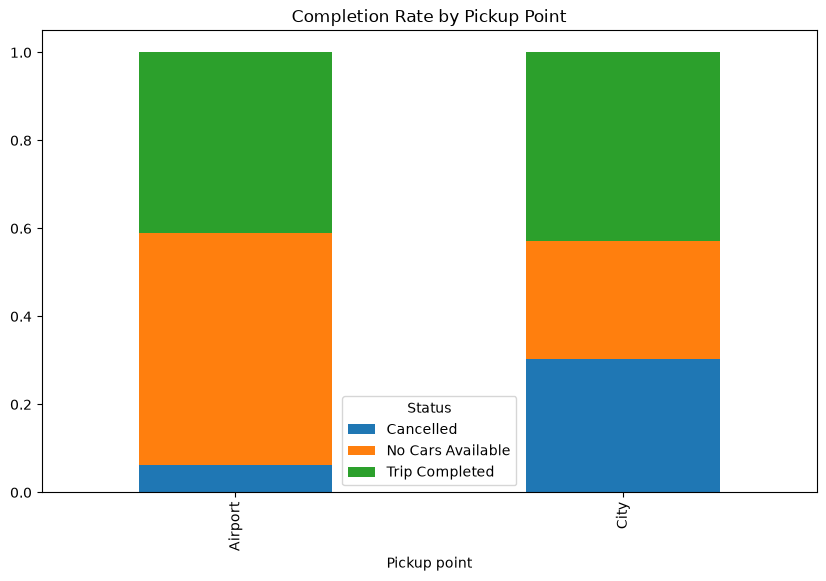

In [27]:
rate=pd.crosstab(
df['Pickup point'],
df['Status']
)

rate.div(
rate.sum(axis=1),
axis=0
).plot(
kind='bar',
stacked=True,
figsize=(10,6)
)

plt.title(
'Completion Rate by Pickup Point'
)

plt.show()

# Insight
- Compare operational efficiency

# Chart 20 — Trip Duration Trend (Line Chart)
### Why I picked this chart

Shows whether longer rides impact availability.

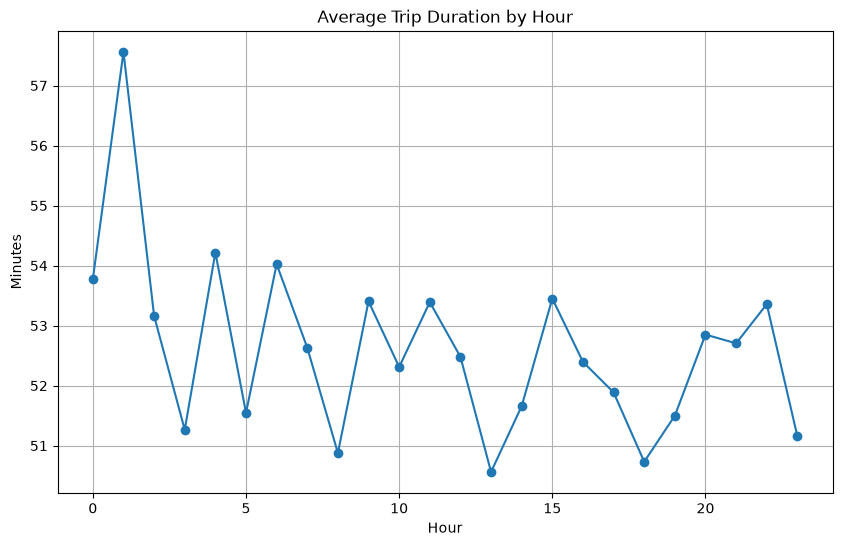

In [28]:
duration=df.groupby(
'Request_Hour'
)['Trip_Duration_Min'].mean()

duration.plot(
marker='o',
figsize=(10,6)
)

plt.title(
'Average Trip Duration by Hour'
)

plt.xlabel(
'Hour'
)

plt.ylabel(
'Minutes'
)

plt.grid()

plt.show()

# Insight
- Understand driver utilization patterns


# Final Business Recommendations

1. Increase supply during demand spikes.
2. Improve allocation logic.
3. Reduce cancellation frequency.
4. Deploy predictive analytics.
5. Improve operational efficiency.

# Conclusion

This project performed Exploratory Data Analysis (EDA) on Uber Request Data to understand customer demand, ride completion patterns, and operational challenges. The analysis showed that many ride requests failed mainly because of No Cars Available and ride cancellations, especially during peak hours.

By analyzing request timing, pickup locations, trip status, and ride trends, important business insights were identified. The results suggest that improving driver availability, optimizing ride allocation, and forecasting demand can reduce failed requests and improve customer satisfaction.

Overall, this project demonstrates how data analysis and visualization can help make better business decisions and improve operational efficiency in ride-hailing services.
